In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

wti   = yf.download("CL=F", start="2016-04-01", end="2026-03-31")
brent = yf.download("BZ=F", start="2016-04-01", end="2026-03-31")

wti_close   = wti["Close"].squeeze()
wti_volume  = wti["Volume"].squeeze()
brent_close = brent["Close"].squeeze()
brent_volume = brent["Volume"].squeeze()

data = pd.concat([wti_close, wti_volume, brent_close, brent_volume], axis=1)
data.columns = ["WTI_Price", "WTI_Volume", "Brent_Price", "Brent_Volume"]
data.dropna(inplace=True)

data["WTI_Volume"] = data["WTI_Volume"].replace(0, np.nan)
data["Brent_Volume"] = data["Brent_Volume"].replace(0, np.nan)

data["WTI_Return"]   = np.log(data["WTI_Price"] / data["WTI_Price"].shift(1))
data["Brent_Return"] = np.log(data["Brent_Price"] / data["Brent_Price"].shift(1))

data["WTI_Vol_Change"]   = np.log(data["WTI_Volume"] / data["WTI_Volume"].shift(1))
data["Brent_Vol_Change"] = np.log(data["Brent_Volume"] / data["Brent_Volume"].shift(1))

data["WTI_Vol"]   = data["WTI_Return"].rolling(21).std() * np.sqrt(252)
data["Brent_Vol"] = data["Brent_Return"].rolling(21).std() * np.sqrt(252)

data["D_COVID"]  = ((data.index >= "2020-03-01") & (data.index <= "2021-06-30")).astype(int)
data["D_RUSSIA"] = ((data.index >= "2022-02-24") & (data.index <= "2023-09-30")).astype(int)
data["D_IRAN"]   = (data.index >= "2023-10-07").astype(int)

data.dropna(inplace=True)
data = data.replace([np.inf, -np.inf], np.nan).dropna()

data.to_csv("oil_processed.csv")
print(f"Final Data shape: {data.shape}")
print(data.tail())

print("\n--- Missing Values ---")
print(data.isnull().sum())

print("\n--- Basic Stats ---")
print(data[["WTI_Return", "Brent_Return", "WTI_Vol", "Brent_Vol", "WTI_Vol_Change", "Brent_Vol_Change"]].describe().round(4))

C:\Users\workk\AppData\Local\Temp\ipykernel_31576\3213640966.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  wti   = yf.download("CL=F", start="2016-04-01", end="2026-03-31")
[*********************100%***********************]  1 of 1 completed
C:\Users\workk\AppData\Local\Temp\ipykernel_31576\3213640966.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  brent = yf.download("BZ=F", start="2016-04-01", end="2026-03-31")
[*********************100%***********************]  1 of 1 completed
D:\Anaconda\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Final Data shape: (2457, 13)
             WTI_Price  WTI_Volume  Brent_Price  Brent_Volume  WTI_Return  \
Date                                                                        
2026-03-24   92.349998    420067.0   104.489998       68614.0    0.046773   
2026-03-25   90.320000    405170.0   102.220001       53714.0   -0.022227   
2026-03-26   94.480003    350768.0   108.010002       28970.0    0.045029   
2026-03-27   99.639999    374920.0   112.570000       18402.0    0.053175   
2026-03-30  102.879997    374075.0   112.779999       15053.0    0.032000   

            Brent_Return  WTI_Vol_Change  Brent_Vol_Change   WTI_Vol  \
Date                                                                   
2026-03-24      0.044521       -0.462061         -0.501825  0.934122   
2026-03-25     -0.021964       -0.036107         -0.244823  0.939214   
2026-03-26      0.055096       -0.144182         -0.617413  0.942158   
2026-03-27      0.041351        0.066588         -0.453801  0.946773   

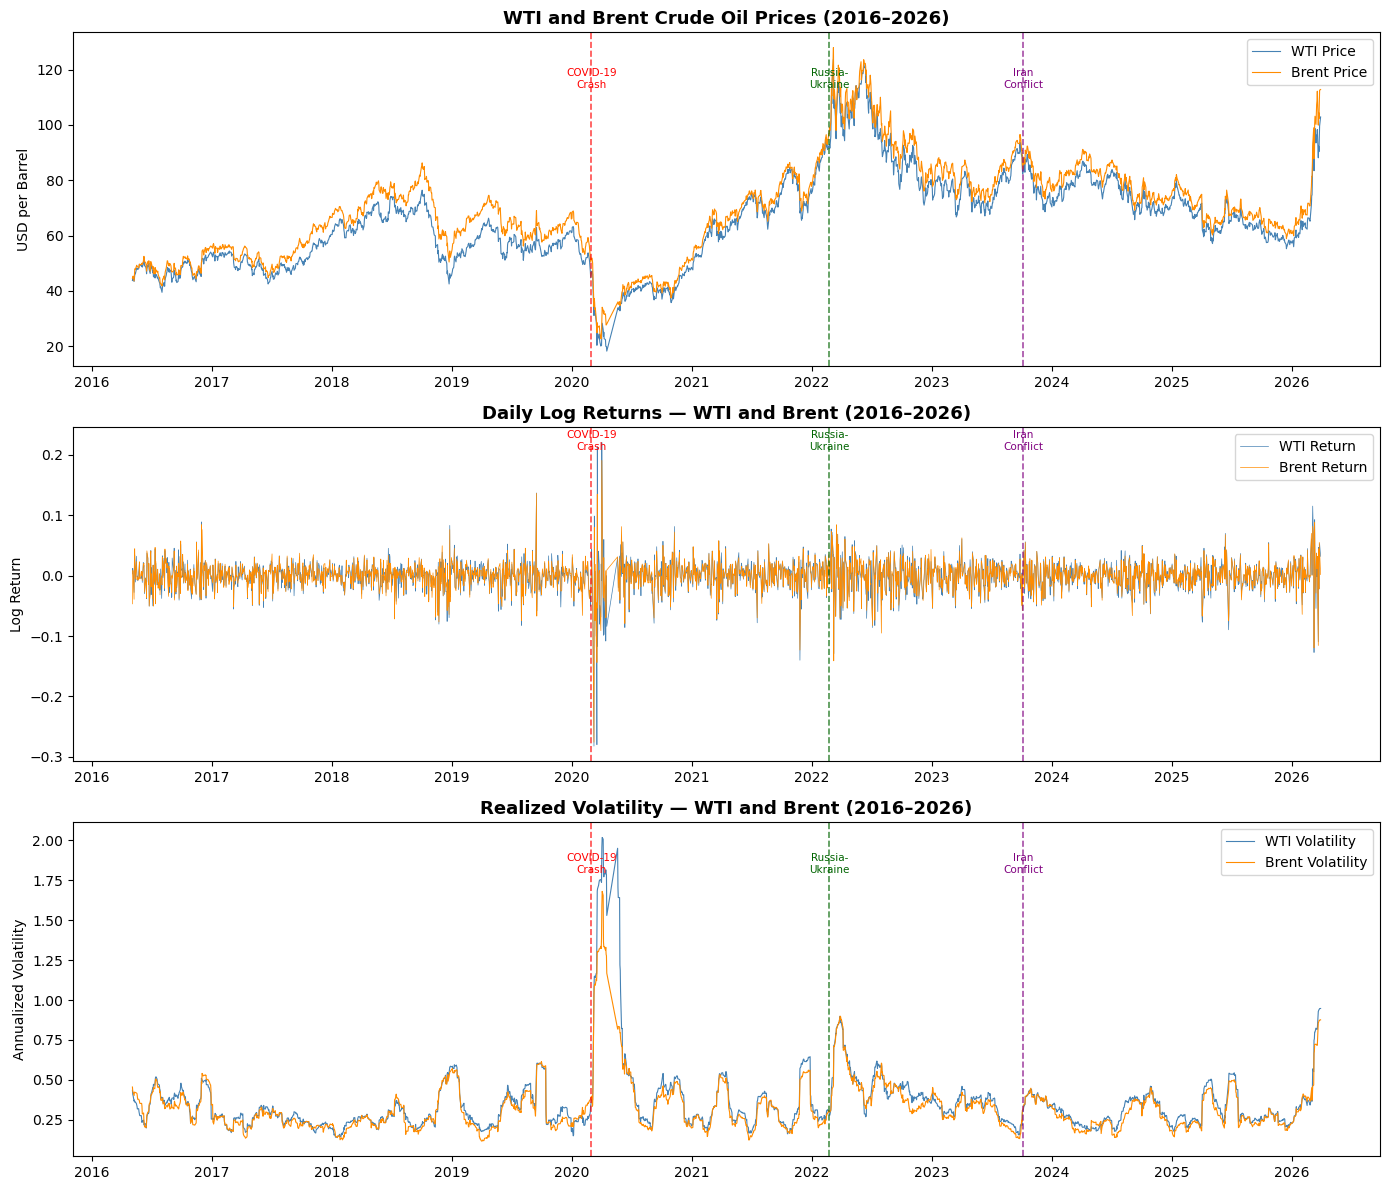

Graph saved!


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv("oil_processed.csv", index_col=0, parse_dates=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Plot 1: Prices ---
axes[0].plot(df.index, df['WTI_Price'], 
             label='WTI Price', color='steelblue', linewidth=0.8)
axes[0].plot(df.index, df['Brent_Price'], 
             label='Brent Price', color='darkorange', linewidth=0.8)
axes[0].set_title('WTI and Brent Crude Oil Prices (2016–2026)', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('USD per Barrel')
axes[0].legend()

# --- Plot 2: Returns ---
axes[1].plot(df.index, df['WTI_Return'], 
             label='WTI Return', color='steelblue', linewidth=0.5)
axes[1].plot(df.index, df['Brent_Return'], 
             label='Brent Return', color='darkorange', linewidth=0.5)
axes[1].set_title('Daily Log Returns — WTI and Brent (2016–2026)', 
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log Return')
axes[1].legend()

# --- Plot 3: Volatility ---
axes[2].plot(df.index, df['WTI_Vol'], 
             label='WTI Volatility', color='steelblue', linewidth=0.8)
axes[2].plot(df.index, df['Brent_Vol'], 
             label='Brent Volatility', color='darkorange', linewidth=0.8)
axes[2].set_title('Realized Volatility — WTI and Brent (2016–2026)', 
                   fontsize=13, fontweight='bold')
axes[2].set_ylabel('Annualized Volatility')
axes[2].legend()

# --- Add event lines to ALL plots ---
events = {
    '2020-03-01': ('COVID-19\nCrash', 'red'),
    '2022-02-24': ('Russia-\nUkraine', 'darkgreen'),
    '2023-10-07': ('Iran\nConflict', 'purple')
}

for ax in axes:
    for date, (label, color) in events.items():
        ax.axvline(pd.Timestamp(date), 
                   color=color, linestyle='--', linewidth=1.2, alpha=0.7)
        ax.text(pd.Timestamp(date), ax.get_ylim()[1]*0.85, 
                label, color=color, fontsize=7.5, ha='center')

plt.tight_layout()
plt.savefig("oil_market_plots.png", dpi=200, bbox_inches='tight')
plt.show()
print("Graph saved!")